In [1]:
import uproot

path = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/Fitter/dpT/Asimov_StatSyst/toy_0001.root"

f = uproot.open(path)

def walk(obj, prefix=""):
    """Recursively print directory/tree structure."""
    for key in obj.keys(recursive=False):
        full = f"{prefix}/{key}" if prefix else key
        item = obj[key]
        cls = type(item).__name__
        print(f"{full}  [{cls}]")
        # Recurse into subdirectories
        if hasattr(item, "keys") and not hasattr(item, "num_entries"):
            walk(item, full)
        # If it's a TTree, list its branches
        elif hasattr(item, "num_entries"):
            print(f"    -> TTree with {item.num_entries} entries")
            for branch in item.keys():
                print(f"       {branch}")

walk(f)

gundam;1  [ReadOnlyDirectory]
gundam;1/runtime;1  [ReadOnlyDirectory]
gundam;1/runtime;1/date_TNamed;1  [Model_TNamed]
gundam;1/runtime;1/user_TNamed;1  [Model_TNamed]
gundam;1/runtime;1/host_TNamed;1  [Model_TNamed]
gundam;1/runtime;1/pwd_TNamed;1  [Model_TNamed]
gundam;1/runtime;1/os_TNamed;1  [Model_TNamed]
gundam;1/runtime;1/dist_TNamed;1  [Model_TNamed]
gundam;1/runtime;1/arch_TNamed;1  [Model_TNamed]
gundam;1/runtime;1/commandLine_TNamed;1  [Model_TNamed]
gundam;1/build;1  [ReadOnlyDirectory]
gundam;1/build;1/version_TNamed;1  [Model_TNamed]
gundam;1/build;1/root;1  [ReadOnlyDirectory]
gundam;1/build;1/root;1/version_TNamed;1  [Model_TNamed]
gundam;1/build;1/root;1/date_TNamed;1  [Model_TNamed]
gundam;1/build;1/root;1/install_TNamed;1  [Model_TNamed]
gundam;1/config;1  [ReadOnlyDirectory]
gundam;1/config;1/unfoldedJson_TNamed;1  [Model_TNamed]
FitterEngine;1  [ReadOnlyDirectory]
FitterEngine;1/preFit;1  [ReadOnlyDirectory]
FitterEngine;1/preFit;1/parameters;1  [ReadOnlyDirectory]

In [2]:
import uproot, pandas as pd, glob

PROD = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/Fitter/dpT/Asimov_StatSyst'

files = sorted(glob.glob(f"{PROD}/toy_*.root"))
print(f"Found {len(files)} files")
assert files, "No toy files found."

rows = []
for path in files:
    try:
        f = uproot.open(path)
        a = f["FitterEngine/postFit/bestFitStats"].arrays(library="np")
        rows.append({
            "seed":          int(a["toyIndex"][0]),
            "converged":     bool(a["fitConverged"][0]),
            "fit_status":    int(a["fitStatusCode"][0]),
            "cov_status":    int(a["covStatusCode"][0]),
            "edm":           float(a["edmBestFit"][0]),
            "ndof":          int(a["nbDegreeOfFreedom"][0]),
            "llh_total":     float(a["totalLikelihoodAtBestFit"][0]),
            "llh_stat":      float(a["statLikelihoodAtBestFit"][0]),
            "llh_penalty":   float(a["penaltyLikelihoodAtBestFit"][0]),
            "llh_stat_sig":  float(a["selection_reco_dpT"][0][0]),
            "llh_stat_side": float(a["sideband_reco_dpT"][0][0]),
            "llh_pen_tmpl":  float(a["Template_Parameter_true_dpT_lp_genie"][0][0]),
            "llh_pen_xsec":  float(a["Cross_section_Systematics"][0][0]),
            "llh_pen_flux":  float(a["Multisigma_Flux_Systematics"][0][0]),
            "llh_pen_det":   float(a["Detector_Systematics"][0][0]),
        })
    except Exception as e:
        print(f"FAILED {path}: {e}")

df = pd.DataFrame(rows)
print(df)
df.to_csv("toys_summary.csv", index=False)
print(f"{len(df)} toys; {(~df['converged']).sum()} non-converged")

Found 1 files
   seed  converged  fit_status  cov_status           edm  ndof  llh_total  \
0     1       True           0           3  5.380131e-08    19   7.141473   

   llh_stat  llh_penalty  llh_stat_sig  llh_stat_side  llh_pen_tmpl  \
0   1.64763     5.493844      0.733694       0.913936           0.0   

   llh_pen_xsec  llh_pen_flux  llh_pen_det  
0      4.332651      0.493503      0.66769  
1 toys; 0 non-converged


Loaded 1000 toys
  Non-converged:  1
  Imperfect Hess: 4
Using 999 converged toys for plots
chi^2 reference k = 19



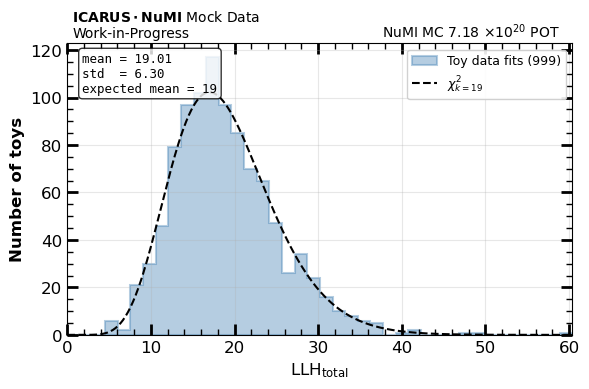

  -> llh_total.png

Done. PNG + PDF written to: /Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/gundam-icarus/Notebooks/Plots/dpT/Asimov_StatSyst


In [3]:
"""
Plot LLH distributions from the stat+syst toy ensemble.
Histogram with chi^2_k overlay, styled to match the mock-data spread plots.

Designed to run in a Jupyter notebook — saves PNGs and displays inline.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

CSV = ("/Users/rvizarreta/Library/CloudStorage/"
       "GoogleDrive-rvizarreta14@gmail.com/My Drive/"
       "🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/"
       "ICARUS/ICARUS_CC0pi_GUNDAM/data/Fitter/dpT/Asimov_StatSyst/"
       "toys_summary.csv")

OUT = ("/Users/rvizarreta/Library/CloudStorage/"
       "GoogleDrive-rvizarreta14@gmail.com/My Drive/"
       "🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/"
       "ICARUS/ICARUS_CC0pi_GUNDAM/gundam-icarus/Notebooks/Plots/dpT/"
       "Asimov_StatSyst")

df = pd.read_csv(CSV)
print(f"Loaded {len(df)} toys")
print(f"  Non-converged:  {(~df['converged']).sum()}")
print(f"  Imperfect Hess: {(df['cov_status'] != 3).sum()}")

# Use only converged toys for the LLH plots
ok = df[df['converged']].copy()
print(f"Using {len(ok)} converged toys for plots")

# k for the chi^2 overlay (ndof from the fit itself)
k_total = int(ok['ndof'].iloc[0])
print(f"chi^2 reference k = {k_total}\n")


def plot_llh(values, k_chi2, xlabel, outfile, nbins=40,
             pot=r"NuMI MC 7.18 $\times 10^{20}$ POT",
             header=r"$\bf{ICARUS \cdot NuMI}$ Mock Data" + "\n" + "Work-in-Progress"):
    """Histogram of LLH values with chi^2_k overlay, styled to match the
    mock-data spread plots (header above the axes, POT in the corner,
    bold axis labels, in-pointing ticks on all four sides)."""

    fig, ax = plt.subplots(figsize=(6, 4))

    counts, edges, _ = ax.hist(
        values, bins=nbins, range=(0, max(values.max(), k_chi2 * 2.5)),
        histtype='stepfilled', alpha=0.4, color='steelblue',
        edgecolor='steelblue', linewidth=1.5,
        label=f'Toy data fits ({len(values)})'
    )

    # chi^2_k overlay, normalized to the histogram's integral
    x = np.linspace(0, edges[-1], 400)
    pdf = chi2.pdf(x, df=k_chi2)
    binwidth = edges[1] - edges[0]
    ax.plot(x, pdf * len(values) * binwidth,
            'k--', linewidth=1.5, label=rf'$\chi^2_{{k={k_chi2}}}$')

    # Empirical summary stats (upper-left, inside)
    mean = values.mean()
    std  = values.std()
    ax.text(0.03, 0.97,
            f"mean = {mean:.2f}\nstd  = {std:.2f}\nexpected mean = {k_chi2}",
            transform=ax.transAxes, ha='left', va='top',
            fontsize=9, family='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Axis labels and limits
    ax.set_xlabel(xlabel, fontsize=12, weight='bold')
    ax.set_ylabel("Number of toys", fontsize=12, weight='bold')
    ax.set_xlim(edges[0], edges[-1])
    ax.set_ylim(bottom=0)

    # Ticks (in-pointing, all four sides, with minor ticks)
    ax.tick_params(axis='both', which='major',
                   labelsize=12, size=8, width=2, direction='in',
                   top=True, right=True, left=True, bottom=True)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor',
                   size=4, width=1, direction='in',
                   top=True, right=True, left=True, bottom=True)

    # ICARUS header (top-left, above the axes) + POT (top-right)
    yr = ax.get_ylim()
    xr = ax.get_xlim()
    y_above = yr[1] + 0.01 * (yr[1] - yr[0])
    ax.text(x=xr[0] + 0.01 * (xr[1] - xr[0]),
            y=y_above, s=header,
            fontsize=10, color='black', verticalalignment='bottom')
    ax.text(x=xr[1] - 0.025 * (xr[1] - xr[0]),
            y=y_above, s=pot,
            fontsize=10, color='black',
            verticalalignment='bottom', horizontalalignment='right')

    # Tick label fonts (match style)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily('sans-serif')

    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
    ax.grid(alpha=0.3)

    fig.tight_layout()
    import os as _os
    _os.makedirs(f"{OUT}/pdf", exist_ok=True)
    fig.savefig(f"{OUT}/{outfile}", dpi=150, bbox_inches='tight')
    fig.savefig(f"{OUT}/pdf/{_os.path.splitext(outfile)[0]}.pdf", bbox_inches='tight')
    plt.show()
    print(f"  -> {outfile}\n")


# ----- LLH_total -----
plot_llh(ok['llh_total'], k_total,
         xlabel=r"$\mathrm{LLH}_{\mathrm{total}}$",
         outfile="llh_total.png")

print("Done. PNG + PDF written to:", OUT)

Loaded 1000 toys
Signal:   (1000, 12)
Sideband: (1000, 12)
CV signal bins:   12,  edges: [  0.  40.  80. 120. 160. 200. 240. 280. 320. 420. 520. 610. 800.]
CV sideband bins: 12, edges: [  0.  40.  80. 120. 160. 200. 240. 280. 320. 420. 520. 610. 800.]


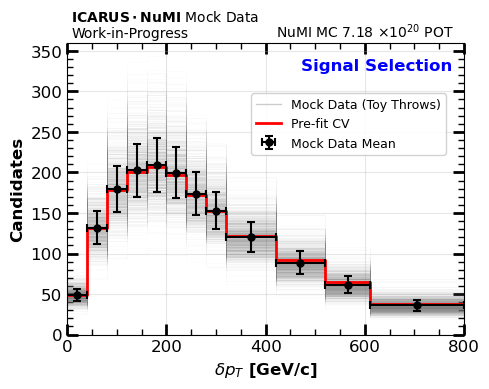

  -> mock_data_signal.png



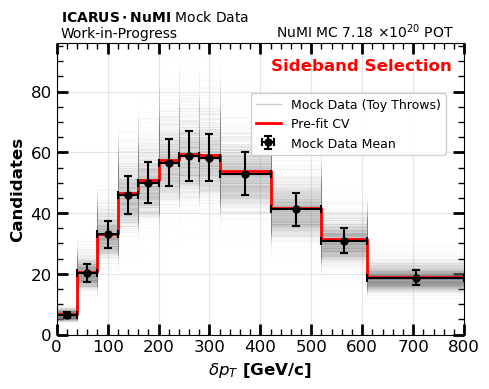

  -> mock_data_sideband.png

Done.


In [4]:
"""
Lane-style mock-data spread plot for the stat+syst toy ensemble.
For each sample (signal, sideband):
  - Red line: pre-fit central value (Asimov prediction)
  - Gray spaghetti: 1000 individual mock-data throws
  - Blue points: mean of mock data per bin with std as error bar

Run after extract_toy_spectra.py produces toys_spectra.csv on the GPVM,
and after scp'ing it to the local data folder.
"""

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt

# --- Paths ---

BASE_DATA = ("/Users/rvizarreta/Library/CloudStorage/"
             "GoogleDrive-rvizarreta14@gmail.com/My Drive/"
             "🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/"
             "ICARUS/ICARUS_CC0pi_GUNDAM/data/Fitter/dpT")

CSV = f"{BASE_DATA}/Asimov_StatSyst/toys_spectra.csv"

# CV comes from the user's existing Asimov fit output
ASIMOV_FIT = f"{BASE_DATA}/Asimov/asimov_dpT.root"

OUT = ("/Users/rvizarreta/Library/CloudStorage/"
       "GoogleDrive-rvizarreta14@gmail.com/My Drive/"
       "🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/"
       "ICARUS/ICARUS_CC0pi_GUNDAM/gundam-icarus/Notebooks/Plots/dpT/"
       "Asimov_StatSyst")

CV_PATH_TEMPLATE = (
    "FitterEngine/preFit/plots/histograms/{sample}/reco_dpT_lp/MC_TH1D"
)

# --- Load data ---

df = pd.read_csv(CSV)
print(f"Loaded {len(df)} toys")

sig_cols  = [c for c in df.columns if c.startswith("sig_bin_")]
side_cols = [c for c in df.columns if c.startswith("side_bin_")]

sig_throws  = df[sig_cols].to_numpy()    # (n_toys, n_bins)
side_throws = df[side_cols].to_numpy()

print(f"Signal:   {sig_throws.shape}")
print(f"Sideband: {side_throws.shape}")

# --- Load CV from the Asimov fit ROOT file ---

asimov = uproot.open(ASIMOV_FIT)

sig_cv,  sig_edges  = asimov[CV_PATH_TEMPLATE.format(sample="selection_reco_dpT")].to_numpy()
side_cv, side_edges = asimov[CV_PATH_TEMPLATE.format(sample="sideband_reco_dpT") ].to_numpy()

print(f"CV signal bins:   {len(sig_cv)},  edges: {sig_edges}")
print(f"CV sideband bins: {len(side_cv)}, edges: {side_edges}")


def plot_lane(throws, cv, edges, sample_label, color_label, outfile,
              xlabel=r"$\delta p_T$ [GeV/c]",
              ylabel="Candidates",
              pot=r"NuMI MC 7.18 $\times 10^{20}$ POT"):
    """Lane-style mock-data spread plot."""

    fig, ax = plt.subplots(figsize=(5, 4))

    centers = (edges[:-1] + edges[1:]) / 2
    widths  = np.diff(edges)

    # --- Gray spaghetti: each toy's mock data as a step line ---
    for i in range(throws.shape[0]):
        ax.step(edges, np.append(throws[i], throws[i, -1]),
                where='post', color='gray', alpha=0.04, linewidth=0.4,
                zorder=2)

    # Single proxy entry for the legend
    ax.step([], [], color='gray', alpha=0.4, linewidth=1.0,
            label='Mock Data (Toy Throws)')

    # --- Mean and std of the toy throws per bin (black points) ---
    mean = throws.mean(axis=0)
    std  = throws.std(axis=0)
    ax.errorbar(
        centers, mean,
        xerr=widths / 2, yerr=std,
        fmt='o', color='black', markersize=5,
        capsize=3, elinewidth=1.5, capthick=1.5,
        label='Mock Data Mean', zorder=5
    )

    # --- Red CV line ---
    ax.step(edges, np.append(cv, cv[-1]),
            where='post', color='red', linewidth=2,
            label='Pre-fit CV', zorder=4)

    # --- Styling consistent with the user's other plots ---
    ax.set_xlabel(xlabel, fontsize=12, weight='bold')
    ax.set_ylabel(ylabel, fontsize=12, weight='bold')
    ax.set_xlim(edges[0], edges[-1])
    ax.set_ylim(bottom=0)

    ax.tick_params(axis='both', which='major',
                   labelsize=12, size=8, width=2, direction='in',
                   top=True, right=True, left=True, bottom=True)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor',
                   size=4, width=1, direction='in',
                   top=True, right=True, left=True, bottom=True)

    # Title block (ICARUS-style)
    yr = ax.get_ylim()
    xr = ax.get_xlim()
    ax.text(x=xr[0] + 0.01 * (xr[1] - xr[0]),
            y=yr[1] + 0.01 * (yr[1] - yr[0]),
            s = r"$\bf{ICARUS \cdot NuMI}$ Mock Data" + "\n" + "Work-in-Progress",
            fontsize=10, color='black', verticalalignment='bottom')
    ax.text(x=xr[1] - 0.025 * (xr[1] - xr[0]),
            y=yr[1] + 0.01 * (yr[1] - yr[0]),
            s=pot,
            fontsize=10, color='black',
            verticalalignment='bottom', horizontalalignment='right')

    # Sample label inside the plot
    ax.text(0.97, 0.95, sample_label,
            transform=ax.transAxes,
            fontsize=12, color=color_label, weight='bold',
            ha='right', va='top')

    ax.legend(loc='upper right', fontsize=9, framealpha=0.9, bbox_to_anchor=(0.97, 0.85))
    ax.grid(alpha=0.3)

    fig.tight_layout()
    import os as _os
    _os.makedirs(f"{OUT}/pdf", exist_ok=True)
    fig.savefig(f"{OUT}/{outfile}", dpi=150, bbox_inches='tight')
    fig.savefig(f"{OUT}/pdf/{_os.path.splitext(outfile)[0]}.pdf", bbox_inches='tight')
    plt.show()
    print(f"  -> {outfile}\n")


# --- Make the two plots ---
plot_lane(sig_throws,  sig_cv,  sig_edges,
          sample_label="Signal Selection", color_label='blue',
          outfile="mock_data_signal.png")

plot_lane(side_throws, side_cv, side_edges,
          sample_label="Sideband Selection", color_label='red',
          outfile="mock_data_sideband.png")

print("Done.")